Sample Data:


/tmp/ipython-input-1211486658.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "pickup_time": pd.date_range("2024-01-01", periods=500, freq="H")


,distance_km,fare_amount,pickup_time
0,11.861663,573.621286,2024-01-01 00:00:00
1,28.570715,452.072275,2024-01-01 01:00:00
2,22.227824,282.145712,2024-01-01 02:00:00
3,18.361096,660.346265,2024-01-01 03:00:00
4,5.524541,563.548379,2024-01-01 04:00:00



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   distance_km  500 non-null    float64       
 1   fare_amount  500 non-null    float64       
 2   pickup_time  500 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2)
memory usage: 11.8 KB

Statistical Summary:


,distance_km,fare_amount,pickup_time
count,500.000000,500.000000,500
mean,15.458290,411.463546,2024-01-11 09:30:00
min,1.146786,53.474017,2024-01-01 00:00:00
25%,7.997111,221.824436,2024-01-06 04:45:00
50%,15.881749,403.866175,2024-01-11 09:30:00
75%,22.927622,594.752615,2024-01-16 14:15:00
max,29.795979,799.788255,2024-01-21 19:00:00
std,8.661964,214.120093,NaN



Missing Values:
distance_km    0
fare_amount    0
pickup_time    0
dtype: int64


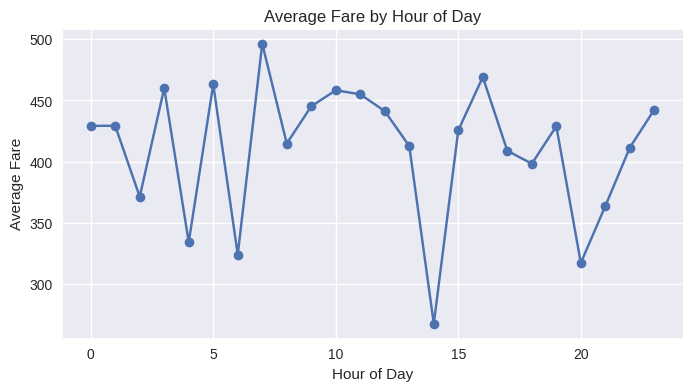

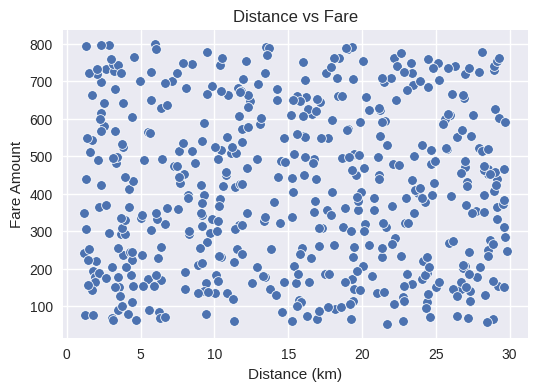

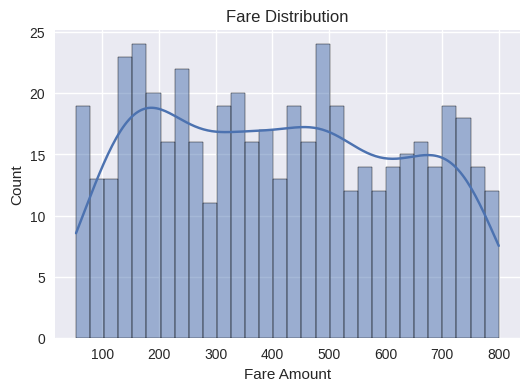


Key Insights from Cab Fare Analysis:
1. Fare generally increases with distance traveled.
2. Peak travel hours show higher average fares.
3. Fare distribution varies significantly based on time and distance.



In [1]:
# ================================
# Cab Fare Analysis and Pricing
# ================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


np.random.seed(42)

df = pd.DataFrame({
    "distance_km": np.random.uniform(1, 30, 500),
    "fare_amount": np.random.uniform(50, 800, 500),
    "pickup_time": pd.date_range("2024-01-01", periods=500, freq="H")
})

print("Sample Data:")
display(df.head())

# -------------------------------
# Dataset Overview
# -------------------------------
print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

# -------------------------------
# Data Cleaning
# -------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

# -------------------------------
# Feature Engineering
# -------------------------------
df["hour"] = df["pickup_time"].dt.hour

# -------------------------------
# Analysis 1: Average Fare by Hour
# -------------------------------
avg_fare_hour = df.groupby("hour")["fare_amount"].mean()

plt.figure(figsize=(8, 4))
avg_fare_hour.plot(kind="line", marker="o")
plt.title("Average Fare by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare")
plt.grid(True)
plt.show()

# -------------------------------
# Analysis 2: Distance vs Fare
# -------------------------------
plt.figure(figsize=(6, 4))
sns.scatterplot(x="distance_km", y="fare_amount", data=df)
plt.title("Distance vs Fare")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount")
plt.show()

# -------------------------------
# Analysis 3: Fare Distribution
# -------------------------------
plt.figure(figsize=(6, 4))
sns.histplot(df["fare_amount"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare Amount")
plt.show()

# -------------------------------
# Key Insights
# -------------------------------
print("""
Key Insights from Cab Fare Analysis:
1. Fare generally increases with distance traveled.
2. Peak travel hours show higher average fares.
3. Fare distribution varies significantly based on time and distance.
""")
